In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
import os

for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

In [3]:
import os
print(os.getcwd())

c:\Users\hp\OneDrive\Documents\Bluestock projects\Bluestock_MF_Analytics\notebooks


In [4]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_counts.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("All datasets loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/06_industry_folio_counts.csv'

In [8]:
import os

files = os.listdir("../data/processed")

for file in files:
    print(file)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
Axis_Bluechip_NAV.csv
HDFC_Top_100_NAV.csv
ICICI_Bluechip_NAV.csv
Kotak_Bluechip_NAV.csv
Nippon_Large_Cap_NAV.csv
SBI_Bluechip_NAV.csv


In [9]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [10]:
print(nav.columns)

print(benchmark.columns)

print(performance.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [11]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


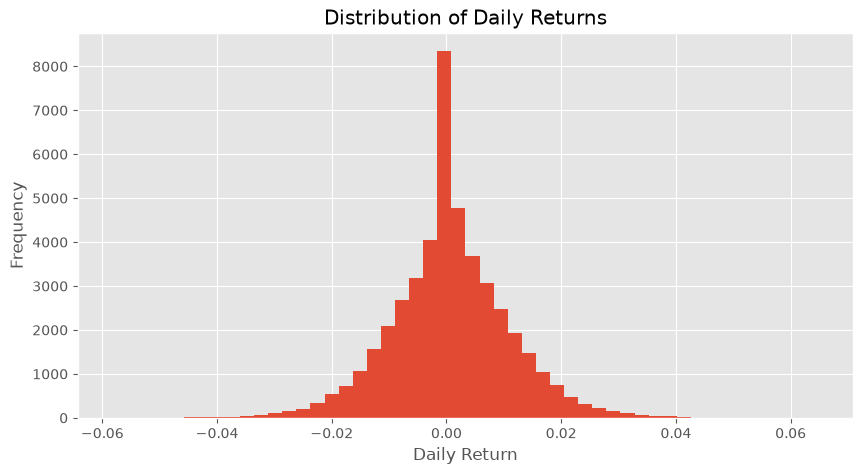

In [12]:
plt.figure(figsize=(10,5))

plt.hist(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [13]:
# First and Last NAV of every fund

cagr = nav.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last"),
    start_date=("date", "first"),
    end_date=("date", "last")
).reset_index()

# Calculate total years
cagr["years"] = (
    (cagr["end_date"] - cagr["start_date"]).dt.days
) / 365.25

# CAGR
cagr["CAGR"] = (
    (cagr["end_nav"] / cagr["start_nav"]) **
    (1 / cagr["years"])
) - 1

cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388


In [14]:
cagr["CAGR (%)"] = cagr["CAGR"] * 100

cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR,CAGR (%)
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371,2.637074
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582,4.458210
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232,30.123153
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384,23.538361
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388,7.938765


In [15]:
fund_names = performance[["amfi_code", "scheme_name"]]

cagr = cagr.merge(
    fund_names,
    on="amfi_code",
    how="left"
)

cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR,CAGR (%),scheme_name
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371,2.637074,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582,4.458210,HDFC Short Term Debt Fund - Regular - Growth
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384,23.538361,ABSL Frontline Equity Fund - Regular - Growth
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388,7.938765,ABSL Small Cap Fund - Regular - Growth


In [16]:
top_cagr = cagr.sort_values(
    "CAGR (%)",
    ascending=False
)

top_cagr.head(10)

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR,CAGR (%),scheme_name
25,120505,135.8720,473.7640,2022-01-03,2026-05-29,4.399726,0.328274,32.827406,ICICI Pru Midcap Fund - Regular - Growth
21,119598,89.8738,309.2050,2022-01-03,2026-05-29,4.399726,0.324235,32.423536,SBI Small Cap Fund - Regular Plan - Growth
39,149324,81.6814,279.7511,2022-01-03,2026-05-29,4.399726,0.322874,32.287440,DSP Small Cap Fund - Regular - Growth
36,148569,28.8620,97.7435,2022-01-03,2026-05-29,4.399726,0.319495,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,70.2514,230.2708,2022-01-03,2026-05-29,4.399726,0.309741,30.974108,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,49.9131,163.2397,2022-01-03,2026-05-29,4.399726,0.309075,30.907455,Kotak Flexicap Fund - Regular - Growth
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,78.4622,245.3651,2022-01-03,2026-05-29,4.399726,0.295811,29.581087,DSP Midcap Fund - Regular - Growth
16,119094,68.3023,203.8581,2022-01-03,2026-05-29,4.399726,0.282144,28.214417,Axis Midcap Fund - Regular - Growth
19,119551,54.3856,149.3216,2022-01-03,2026-05-29,4.399726,0.258047,25.804686,SBI Bluechip Fund - Regular Plan - Growth


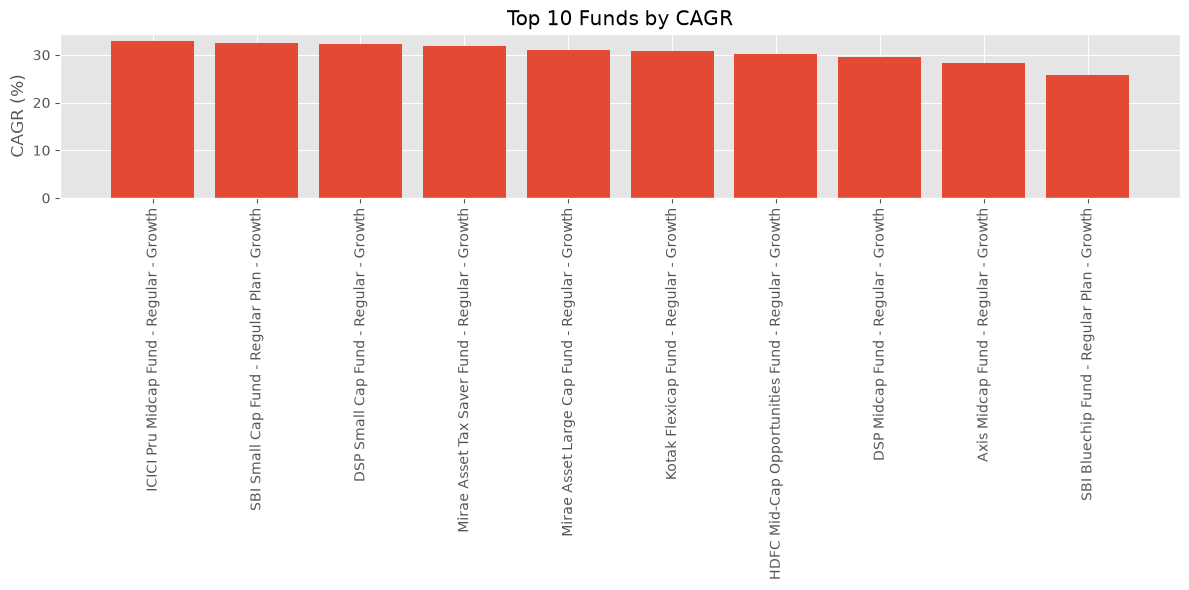

In [17]:
top10 = top_cagr.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["CAGR (%)"]
)

plt.xticks(rotation=90)

plt.ylabel("CAGR (%)")

plt.title("Top 10 Funds by CAGR")

plt.tight_layout()

plt.show()

In [18]:
# Average daily return for each fund
avg_return = nav.groupby("amfi_code")["daily_return"].mean()

# Standard deviation of daily returns
std_return = nav.groupby("amfi_code")["daily_return"].std()

# Assume Risk-Free Rate = 6.5%
rf = 0.065

# Annualized Sharpe Ratio
sharpe = ((avg_return * 252) - rf) / (std_return * np.sqrt(252))

sharpe = sharpe.reset_index()
sharpe.columns = ["amfi_code", "Sharpe_Ratio"]

sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [19]:
sharpe = sharpe.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [20]:
top_sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

top_sharpe.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


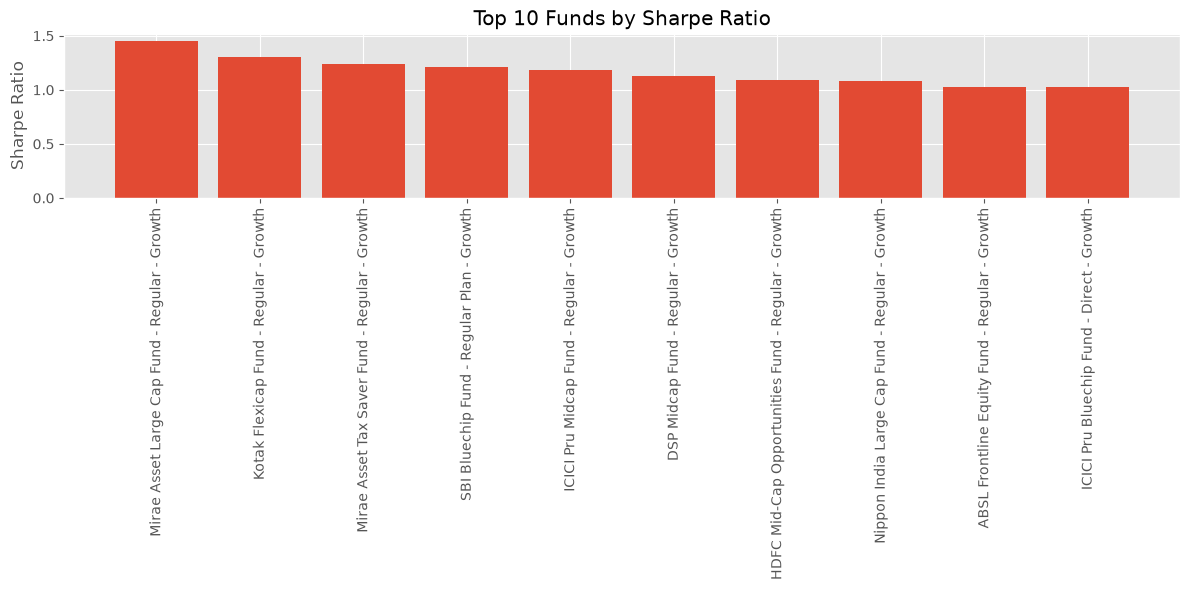

In [21]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sharpe.head(10)["scheme_name"],
    top_sharpe.head(10)["Sharpe_Ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sharpe Ratio")

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.show()

In [22]:
sharpe.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [24]:
# Keep only negative daily returns
negative_returns = nav.copy()

negative_returns["downside_return"] = negative_returns["daily_return"]

negative_returns.loc[
    negative_returns["downside_return"] > 0,
    "downside_return"
] = np.nan

In [25]:
downside_std = negative_returns.groupby("amfi_code")["downside_return"].std()

downside_std.head()

amfi_code
100016    0.005261
100025    0.001483
100033    0.007133
101206    0.005238
101207    0.009562
Name: downside_return, dtype: float64

In [26]:
avg_return = nav.groupby("amfi_code")["daily_return"].mean()

rf = 0.065

sortino = ((avg_return * 252) - rf) / (downside_std * np.sqrt(252))

sortino = sortino.reset_index()

sortino.columns = ["amfi_code", "Sortino_Ratio"]

sortino.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.940851
2,100033,1.829134
3,101206,1.799563
4,101207,0.276456


In [27]:
sortino = sortino.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino.head()

,amfi_code,Sortino_Ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.940851,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276456,ABSL Small Cap Fund - Regular - Growth


In [28]:
top_sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

top_sortino.head(10)

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


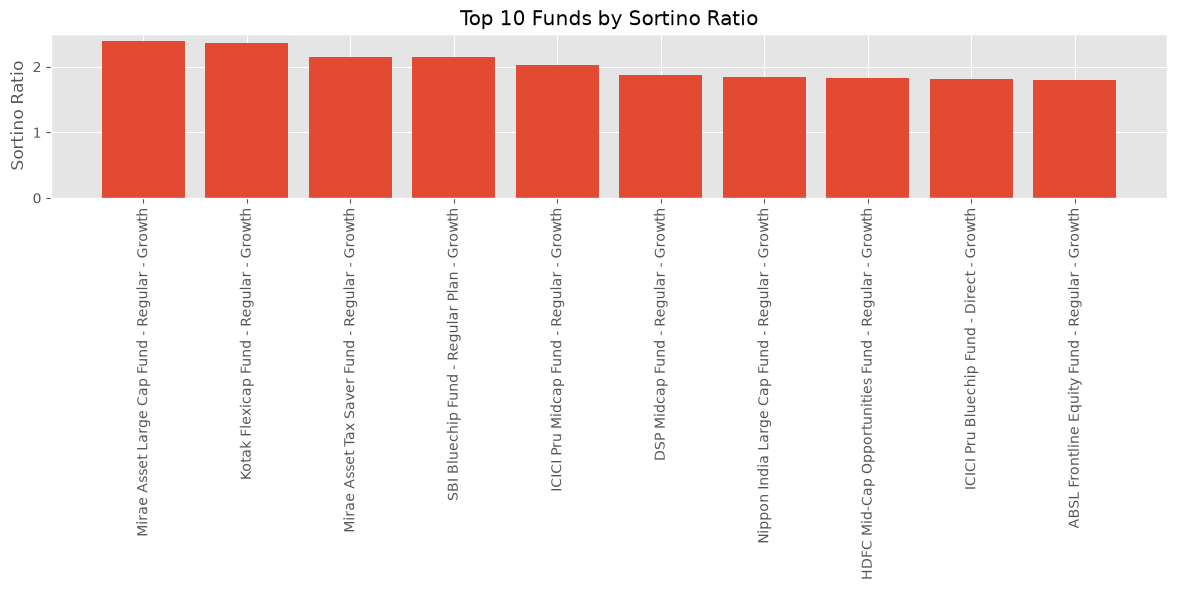

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sortino.head(10)["scheme_name"],
    top_sortino.head(10)["Sortino_Ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sortino Ratio")

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

In [30]:
sortino.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


In [31]:
# Convert date column
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort
benchmark = benchmark.sort_values("date")

# Daily benchmark return
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [32]:
merged = pd.merge(
    nav,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,-0.869574
2,100016,2022-01-03,520.4608,NaN,3.261121
3,100016,2022-01-03,520.4608,NaN,-0.850741
4,100016,2022-01-03,520.4608,NaN,11.251899


In [33]:
merged = merged.dropna(
    subset=["daily_return", "benchmark_return"]
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
7,100016,2022-01-04,515.0971,-0.010306,-0.333839
8,100016,2022-01-04,515.0971,-0.010306,-0.871020
9,100016,2022-01-04,515.0971,-0.010306,-0.363055
10,100016,2022-01-04,515.0971,-0.010306,11.067710
11,100016,2022-01-04,515.0971,-0.010306,-0.432404


In [34]:
alpha_beta = []

for fund in merged["amfi_code"].unique():

    temp = merged[merged["amfi_code"] == fund]

    if len(temp) > 30:

        beta, alpha, r_value, p_value, std_err = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": fund,
            "Alpha": alpha * 252,
            "Beta": beta
        })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [35]:
alpha_beta = alpha_beta.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037661,-0.000003,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.044818,-0.000003,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.265138,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.208464,0.000011,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.109861,-0.000005,ABSL Small Cap Fund - Regular - Growth


In [36]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta saved successfully!")

Alpha Beta saved successfully!


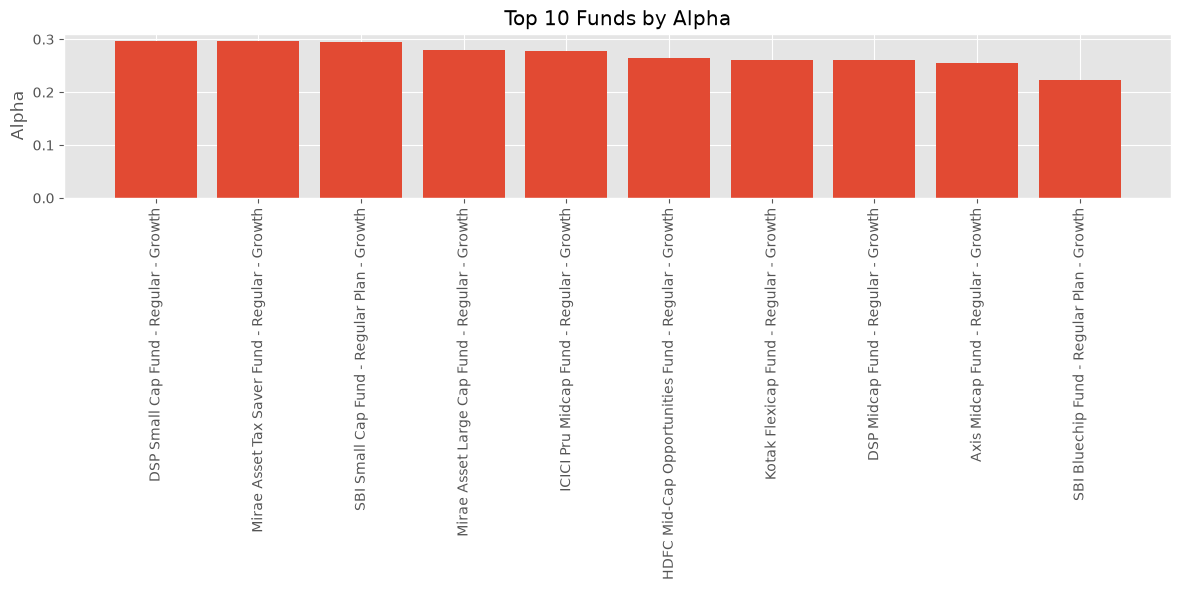

In [37]:
top_alpha = alpha_beta.sort_values(
    "Alpha",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_alpha["scheme_name"],
    top_alpha["Alpha"]
)

plt.xticks(rotation=90)

plt.ylabel("Alpha")

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.show()

In [38]:
# Maximum Drawdown Calculation

mdd_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    temp = temp.sort_values("date")

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] - temp["running_max"]
    ) / temp["running_max"]

    mdd = temp["drawdown"].min()

    mdd_results.append({
        "amfi_code": fund,
        "Maximum_Drawdown": mdd
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [40]:
mdd_df = mdd_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

mdd_df.head()

,amfi_code,Maximum_Drawdown,scheme_name_x,scheme_name_y
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth


In [41]:
mdd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved successfully!")

Maximum Drawdown saved successfully!


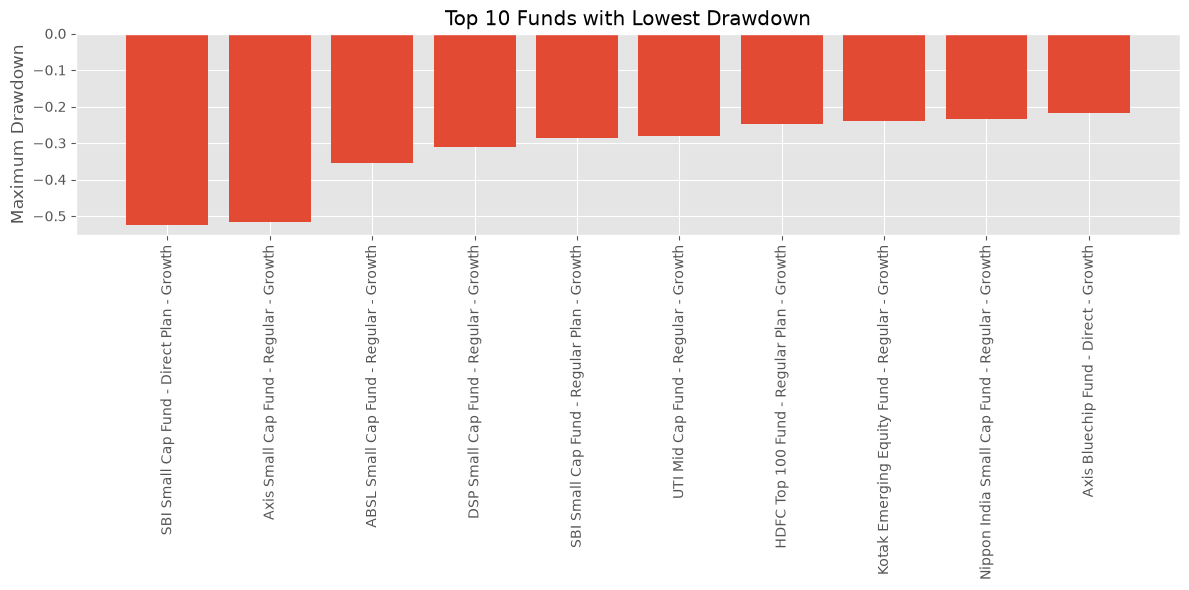

In [45]:
top_mdd = mdd_df.sort_values(
    "Maximum_Drawdown"
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_mdd["scheme_name_x"],
    top_mdd["Maximum_Drawdown"]
)

plt.xticks(rotation=90)

plt.ylabel("Maximum Drawdown")

plt.title("Top 10 Funds with Lowest Drawdown")

plt.tight_layout()

plt.show()

In [44]:
print(mdd_df.columns)

Index(['amfi_code', 'Maximum_Drawdown', 'scheme_name_x', 'scheme_name_y'], dtype='str')


In [46]:
mdd_df = mdd_df.drop(columns=["scheme_name_y"])
mdd_df = mdd_df.rename(columns={"scheme_name_x": "scheme_name"})

print(mdd_df.columns)

Index(['amfi_code', 'Maximum_Drawdown', 'scheme_name'], dtype='str')


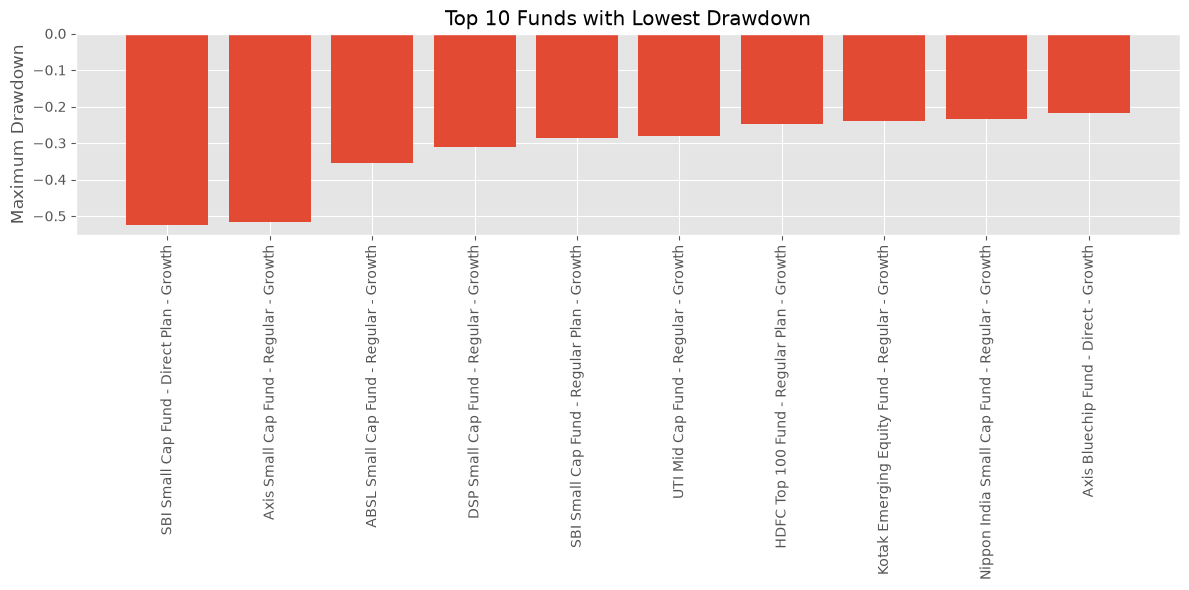

In [47]:
top_mdd = mdd_df.sort_values("Maximum_Drawdown").head(10)

plt.figure(figsize=(12,6))
plt.bar(top_mdd["scheme_name"], top_mdd["Maximum_Drawdown"])
plt.xticks(rotation=90)
plt.ylabel("Maximum Drawdown")
plt.title("Top 10 Funds with Lowest Drawdown")
plt.tight_layout()
plt.show()

In [48]:
fund_scorecard = (
    cagr[["amfi_code", "scheme_name", "CAGR (%)"]]
    .merge(sharpe, on=["amfi_code", "scheme_name"])
    .merge(sortino, on=["amfi_code", "scheme_name"])
    .merge(alpha_beta, on=["amfi_code", "scheme_name"])
    .merge(mdd_df, on=["amfi_code", "scheme_name"])
)

fund_scorecard.head()

,amfi_code,scheme_name,CAGR (%),Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Maximum_Drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2.637074,-0.201517,-0.351047,0.037661,-0.000003,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.458210,-0.567095,-0.940851,0.044818,-0.000003,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.123153,1.093699,1.829134,0.265138,0.000012,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,23.538361,1.027213,1.799563,0.208464,0.000011,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,7.938765,0.162661,0.276456,0.109861,-0.000005,-0.354469


In [49]:
fund_scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


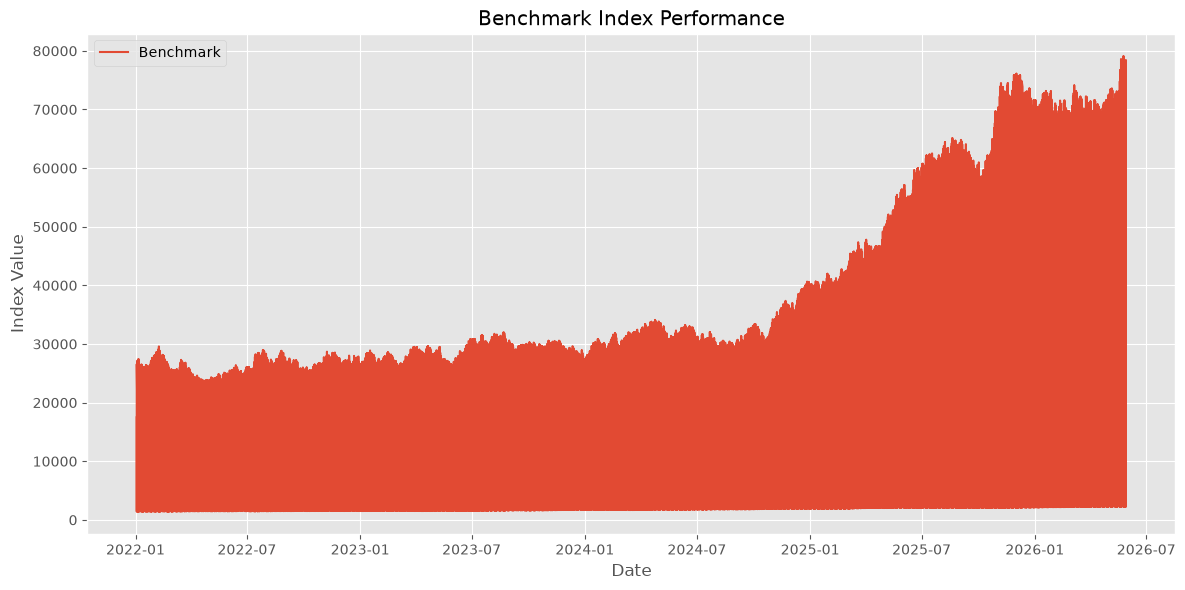

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    benchmark["date"],
    benchmark["close_value"],
    label="Benchmark"
)

plt.title("Benchmark Index Performance")

plt.xlabel("Date")

plt.ylabel("Index Value")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

# Business Insights

1. Funds with higher CAGR generally provide better long-term returns.
2. Higher Sharpe Ratio indicates better risk-adjusted performance.
3. Sortino Ratio focuses on downside risk and provides additional insights.
4. Beta greater than 1 indicates higher volatility than the benchmark.
5. Positive Alpha suggests a fund has outperformed its benchmark.
6. Maximum Drawdown helps identify downside risk during market corrections.
7. Benchmark comparison highlights relative fund performance.
8. Combining multiple metrics provides a balanced evaluation of funds.
9. Long-term investing generally smooths short-term market volatility.
10. Fund scorecards assist investors in comparing multiple schemes objectively.

# Conclusion

Fund Performance Analytics evaluated mutual fund performance using CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown. These metrics provide a comprehensive view of returns, risk, and benchmark-relative performance, helping investors make informed investment decisions.